# Streaming
## Review
In module 2, covered a few ways to customize graph state (`state_schema.ipynb`) and memory.

We built up to a Chatbot with external memory that can sustain long-running conversations.

## Goals
This module will dive into `human-in-the-loop`, which builds on memory and allows users to interact directly with graphs in various ways.

To set the stage for `human-in-the-loop`, we'll first dive into streaming, which provides several ways to visualize graph output over the course of execution.

## Streaming
LangGraph is built with first class support for streaming. Let's set up the Chatbot from Module 2, and show various way to stream outputs from the graph during execution.


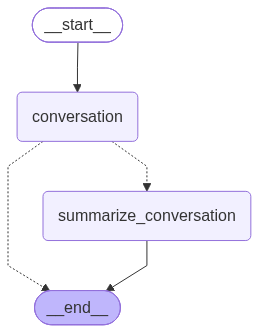

In [10]:
# Import libraries
import os, getpass
from dotenv import load_dotenv
from typing import Literal
from IPython.display import Image, display

from langgraph.graph import MessagesState,StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, RemoveMessage
from langchain_core.runnables import RunnableConfig

# Load env variable for API Key
load_dotenv()
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL")

# Set the Chat Model
model = ChatOpenAI(
    model="deepseek-v4-pro",  # Or "deepseek-v4-flash" for a faster option
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    temperature=0
)

# State
class State(MessagesState):
    summary: str

def call_model(state: State, config: RunnableConfig):
    """
    Define the logic to call the model.
    """
    summary = state.get("summary", "")
    if summary:
        system_message = f"Summary of conversation earlier: {summary}"
        messages = [SystemMessage(content=system_message)] + state["messages"]
    else:
        messages = state["messages"]
    response = model.invoke(messages, config)
    return {"messages": response}

def summarize_conversation(state: State):
    """
    Summarize the current conversation.
    """
    summary = state.get("summary", "")
    if summary:
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
    else:
        summary_message = "Create a summary of the conversation above:"
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

def should_continue(state: State) -> Literal ["summarize_conversation", END]:
    """
    Determine whether to end or summarize the conversation.
    """
    messages = state["messages"]
    if len(messages) > 6:
        return "summarize_conversation"
    return END

# Define a new graph
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node("summarize_conversation", summarize_conversation)

# Set the entry point as conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))



## Streaming Full State
Now, let's talk about ways to stream our graph state.

`.stream` and `.astream` are sync and async methods for streaming back results. LangGraph supports a few different streaming modes for graph state.
- `values`: This streams the full state of the graph after each node is called.
- `updates`: This streams updates to the state of the graph after each node is called.

Let's look at `stream_mode="updates"`. Because we stream with `updates`, we only see updates to the state after node in the graph is run. Each `chunk` is a dict with `node_name` as the key and the updated state as the value.

In [11]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

for chunk in graph.stream({"messages": [HumanMessage(content="Hi, I'm Lance")]}, config, stream_mode="updates"):
    chunk["conversation"]["messages"].pretty_print()

config = {"configurable": {"thread_id": "2"}}

input_message = HumanMessage(content="Hi, I'm Lance")
for event in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    for m in event["messages"]:
        m.pretty_print()
    print("---"*25)

================================== Ai Message ==================================

Hi Lance! I'm DeepSeek, your friendly AI assistant. How can I help you today?
================================ Human Message =================================

Hi, I'm Lance
---------------------------------------------------------------------------
================================ Human Message =================================

Hi, I'm Lance
================================== Ai Message ==================================

Hi Lance! It's nice to meet you. How can I help you today?
---------------------------------------------------------------------------


## Streaming Tokens
We often want to stream more than graph state. In particular, with chat model calls it is common to stream the tokens as they are generated.

We can do this using the `.astream_events` method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:
- `event`: This is the type of event that is being emitted.
- `name`: This is the name of event.
- `data`: This is the data associated with the event.
- `metadata`: Contains `langgraph_node`, the node emitting the event.

In [12]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}
input_message = HumanMessage(content="Tell me about the 49ers NFL team")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    #print(f"Node: {event["metadata"].get("langgraph_node", "")}")
    continue

The central point is that tokens from chat models within your graph have the `on_chat_model_stream` type.

We can use `event["metadata"]["langgraph_node"]` to select the node to stream from. And we can use `event["data"]` to get the actual data for each event, which in this case is an `AIMessageChunk`.

In [13]:
node_to_stream = "conversation"
# Create a thread
config = {"configurable": {"thread_id": "4"}}
input_message = HumanMessage(content="Tell me about the 49ers NFL team")

async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    if event["event"] == "on_chat_model_stream" and event["metadata"].get("langgraph_node", "") == node_to_stream:
        #print(event["data"])
        continue

In [14]:
# Create a thread
config = {"configurable": {"thread_id": "5"}}
input_message = HumanMessage(content="Tell me about the 49ers NFL team")

async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    if event["event"] == "on_chat_model_stream" and event["metadata"].get("langgraph_node", "") == node_to_stream:
        data = event["data"]
        print(data["chunk"].content, end="|")

|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||Here| is| a| comprehensive| overview| of| the| San| Francisco| |49|ers|,| from| their| early| dominance| to| their| current| status| as| a| perennial| contender|.

|###| At| a| Gl|ance|

|-| **|Team| Name|:**| San| Francisco| |49|ers|
|-| **|Conference|/|Division|:**| National| Football| Conference| (|N|FC|)| West|
|-| **|Founded|:**| |194|6| as| a| charter| member| of| the| All|-Americ|a| Football| Conference| (|AA|FC|),| joined| the| NFL| in| |194|9|.
|-| **|Home| Stadium|:**| Levi|'s| Stadium| (|Santa| Clara|,| California|)
|-| **|Team| Colors|:**| |49|ers| Red|,| Gold|,| and| White|
|-| **|M|asc|ot|:**| S|ourd|ough| Sam| (|a| gold| rush| prosp|ector|)
|-| **|The| Name|:**| The| name| "|49|ers|"| is| a| direct| nod| to| the| prosp|ectors| who| flock|ed| to| Northern| California| during| the| |184|9| Gold| Rush|.

|---
